# 1) Load the data and separate in X all the columns but the last one, in y the last column, then produce a pairplot of X and decide which pair of columns is most interesting for a 2d scatterplot, ad produce the scatterplot

In [44]:
import pandas as pd
data = pd.read_csv("./seeds_dataset.txt", sep="\t", header=None)
X = data.iloc[:,:-1]
y = data.iloc[:,-1]
data

,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,2
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,2
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,2
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,2


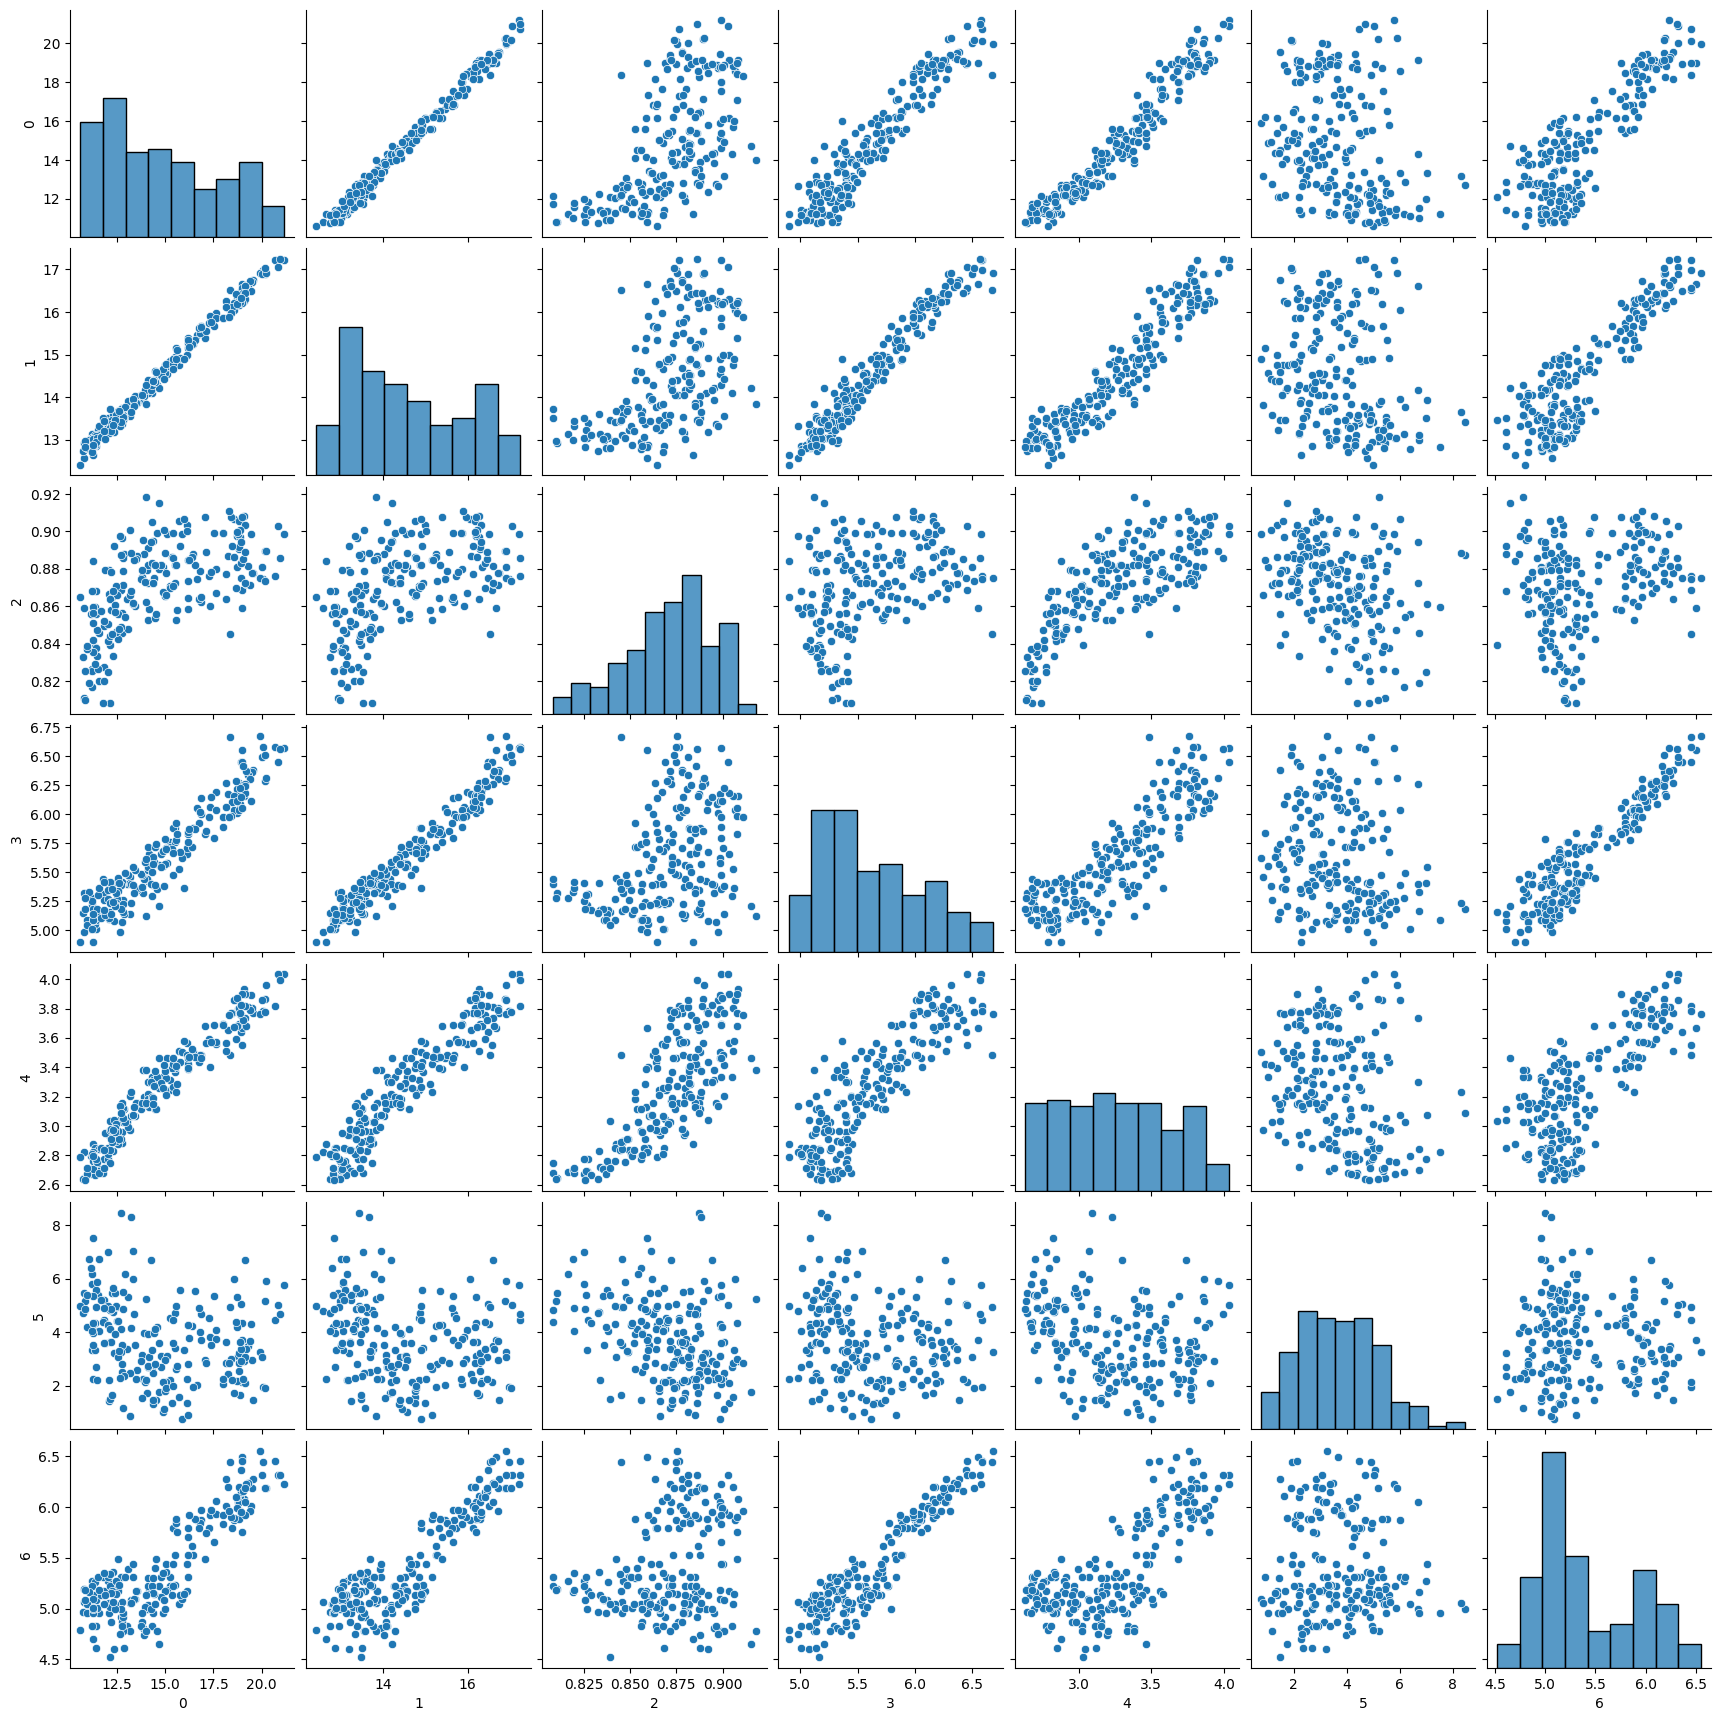

In [45]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.pairplot(data=X);

Most of the pairplots look the same along the diagonal, the pairplots of the $6^{th}$ attribute look more separabl in the middle. 
Then i choose the $3^{rd}$ attribute since the division seems more clear.

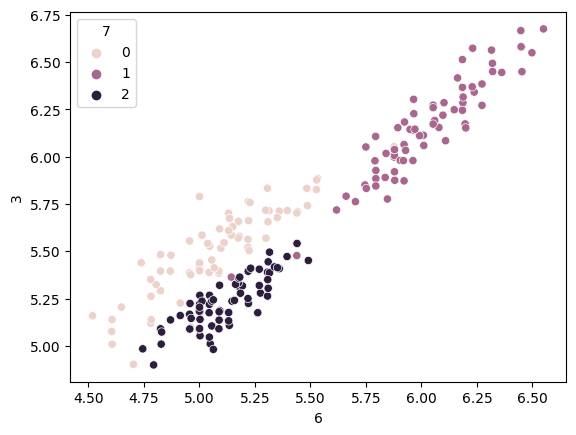

In [46]:
sns.scatterplot(data=data, x=6, y=3, hue=7);

# 2) Find the best clustering scheme for X with a method of your choice, plot ssd and global silhouhette index for an appropriate range of parameters and show the chosen hyperparameter(s) (5pt)
- consider carefully the number of clusters, simple optimisationof the silhouette will not be enough, consider also the elbow plot and decide visually the best number of clusters

In [47]:
from sklearn.cluster import KMeans
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score

parameters_list = ParameterGrid({
    "n_clusters" : [*range(2,11)],
    # "algorithm" : ["lloyd", "elkan"],
    # "init" : ["k-means++", "random"]
})

silhouette_list = []
inertia_list = []
random_state = 42
for parameters in parameters_list:
    model = KMeans(**parameters, random_state=random_state)
    y_pred = model.fit_predict(X)
    inertia_list.append(model.inertia_)
    silhouette_list.append(silhouette_score(X,y_pred))
    

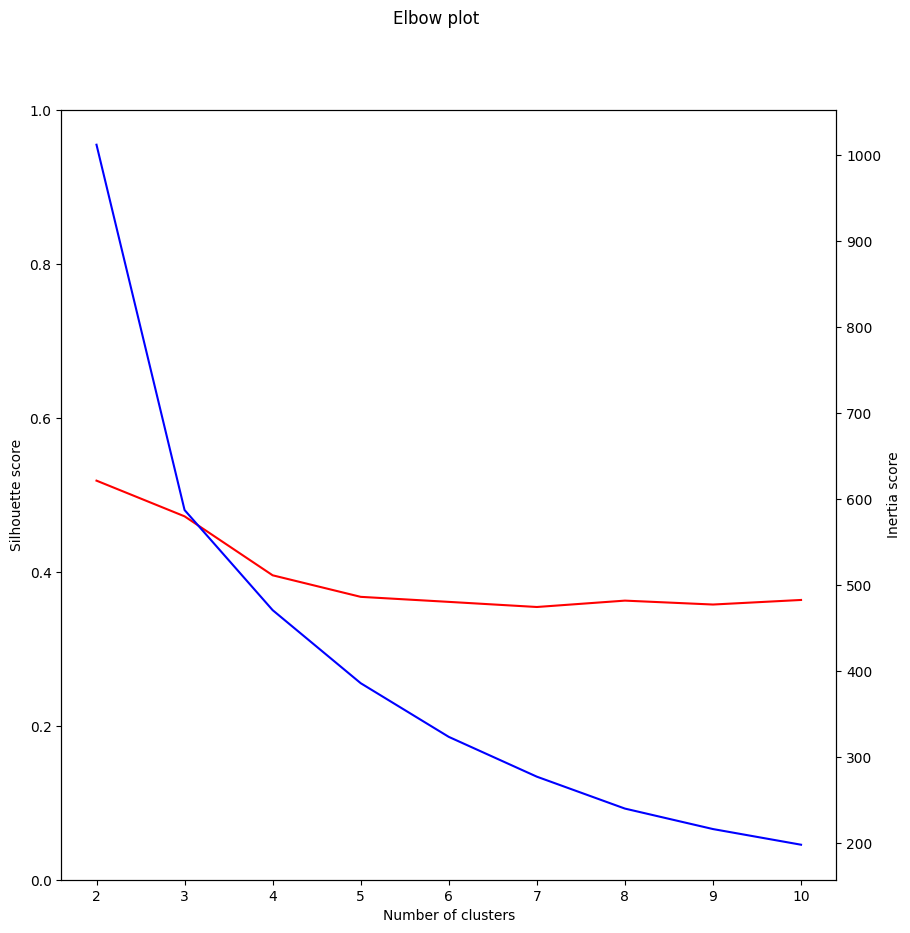

In [48]:
import matplotlib.pyplot as plt 
num_clusters = [*range(2,11)]
fig, ax1 = plt.subplots(1,1,figsize=[10,10])
fig.suptitle("Elbow plot")

ax1.plot(num_clusters, silhouette_list, c="red")
ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Silhouette score")
ax1.set_ylim(0,1)

ax2 = ax1.twinx()
ax2.plot(num_clusters, inertia_list, c="blue")
ax2.set_ylabel("Inertia score")

plt.show()

As we can see the elbow is in $K=3$, so the best clustering scheme seems to have 3 clusters using `KMeans`.

# 3) Fit the clustering scheme to y_km, then produce the confusion matrix comparing y and y_km with sklearn.metrics.confusion_matrix, the resulting confusion matrix must be "sorted" using the function max_diag provided below, producing the final confusion matrix cm_km 

In [51]:
K = 3

best_model = KMeans(n_clusters=K)
y_km = best_model.fit_predict(X)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, y_km)
print(cm)

from max_diag import max_diag
cm_km = max_diag(cm) # works inplace also

print()
print(cm_km)

[[60  9  1]
 [10  0 60]
 [ 2 68  0]]

[[60.  1.  9.]
 [10. 60.  0.]
 [ 2.  0. 68.]]


# 4) In a comment explain why function max_diag is useful 

In the confusion matrix each row represents the class and the column represents the cluster. `max_diag` is useful because, since each maximum value is in the diagonal, it means that the $i$-th class has its best cluster in $i$-th cluster and so the structured is simplified.

# 5) Compute the accuracy a_km of y_km versus y as the ratio the sum of the main diagonal of cm_km and the number of samples in X

In [52]:
accuracy = sum(cm_km.diagonal()) / X.shape[0]
accuracy

0.8952380952380953

# 6) rescale X using sklearn.preprocessing.MinMaxScaler, producing the scaled dataset X_mms

In [56]:
from sklearn.preprocessing import MinMaxScaler
X_mms = pd.DataFrame(MinMaxScaler().fit_transform(X))
print(X.shape, X_mms.shape)

(210, 7) (210, 7)


# 7) Repeat point 3 and 5 above,fittingX_mms to y_km_mms and producing the confusion matrix cm_km_mms reordered with max_diag and the accuracy a_km_mms as above

In [58]:
# 3) 
K = 3

best_model = KMeans(n_clusters=K)
y_km_mms = best_model.fit_predict(X_mms)

cm_mms = confusion_matrix(y, y_km_mms)
print(cm_mms)

cm_km_mms = max_diag(cm_mms) # works inplace also

print()
print(cm_km_mms)

[[ 2 10 58]
 [62  0  8]
 [ 0 67  3]]

[[58.  2. 10.]
 [ 8. 62.  0.]
 [ 3.  0. 67.]]


In [59]:
# 5) 
accuracy = sum(cm_km_mms.diagonal()) / X_mms.shape[0]
accuracy

0.8904761904761904